## Unsupervised ML : Clustering

In [1]:
### autoreloader
%load_ext autoreload
%autoreload 2

In [2]:
### setting up the system path
import sys
sys.path.append('../')

In [3]:
### importing the functions from the src
from src.basic.basic_processing import load_data, check_nan_duplicates_shape
from src.unsupervised.pca import get_variance, reduce_dimensions, check_shape
from src.unsupervised.clustering import find_k, clusters_kmeans, find_eps, clusters_dbscan, sample_for_hm, plot_dendo, clusters_hm

##### ************ Train data *****************

In [4]:
### setting up the path and loading the data
train_path = '../data/unsupervised_ready/train.csv'
train = load_data(train_path)
train.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,...,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,0,0,0,0,1,0,0,0,0,0,...,0.209694,1.00,0.592437,0.734863,0.366737,0,0.272727,0.400000,0.695652,0.424444
1,1,0,0,1,0,0,1,0,0,1,...,0.387653,0.25,0.130252,0.159358,0.486549,0,0.181818,0.866667,0.217391,0.577225
2,0,0,0,0,1,0,0,1,0,1,...,0.458673,0.50,0.848739,0.457245,0.296030,1,0.727273,0.866667,1.000000,0.254520
3,0,1,0,1,0,0,0,0,0,0,...,0.683633,0.50,0.571429,0.985009,0.336134,0,0.727273,0.300000,0.565217,0.490544
4,0,1,0,1,0,0,0,1,0,0,...,0.911776,0.25,0.029412,0.984885,0.080308,0,0.000000,0.400000,0.260870,0.307802


In [5]:
### initial checks
check_nan_duplicates_shape(train)

Shape : (40000, 33) 
Duplicates : 0 
Transaction_Type_Bank Transfer    0
Transaction_Type_Online           0
Transaction_Type_POS              0
Device_Type_Mobile                0
Device_Type_Tablet                0
Location_Mumbai                   0
Location_New York                 0
Location_Sydney                   0
Location_Tokyo                    0
Merchant_Category_Electronics     0
Merchant_Category_Groceries       0
Merchant_Category_Restaurants     0
Merchant_Category_Travel          0
Card_Type_Discover                0
Card_Type_Mastercard              0
Card_Type_Visa                    0
Authentication_Method_OTP         0
Authentication_Method_PIN         0
Authentication_Method_Password    0
Account_Balance                   0
IP_Address_Flag                   0
Previous_Fraudulent_Activity      0
Daily_Transaction_Count           0
Avg_Transaction_Amount_7d         0
Failed_Transaction_Count_7d       0
Card_Age                          0
Transaction_Distance       

In [6]:
### checking the variance ratio of the data
get_variance(train)

array([0.07119584, 0.05427632, 0.05372449, 0.05338071, 0.05314962,
       0.05284227, 0.05228878, 0.04492973, 0.04331939, 0.04271779,
       0.04256884, 0.04235249, 0.04213654, 0.0419466 , 0.02662346,
       0.02357604, 0.02093968, 0.02051806, 0.01925933, 0.01884403,
       0.01828796, 0.01797185, 0.01783624, 0.01769928, 0.01755428,
       0.01750561, 0.01336916, 0.01325024, 0.01317401, 0.01023579,
       0.00856094, 0.00845761, 0.005507  ])

In [7]:
### reducing the data for the visualisation (PCA)
train_pca = reduce_dimensions(train)
check_shape(train_pca)

(40000, 2)

##### 1. Kmeans clustering

[187941.1629270171, 176798.2221900634, 170128.5857569026, 165703.71526355238, 161702.4200182849, 160085.84198920213, 157146.30462315146, 155485.48071523622, 152369.8439525307, 150783.9245123244, 149327.8273847404]


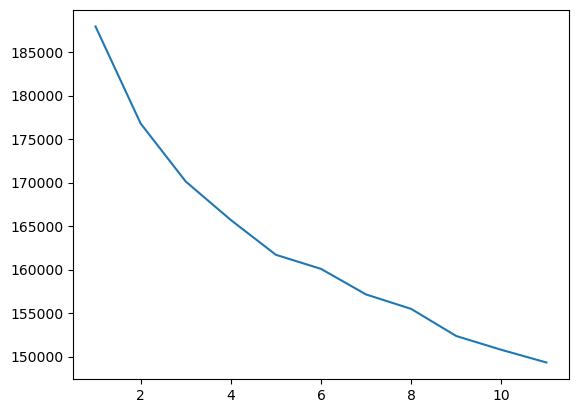

In [8]:
### finding the value of the k
find_k(train)

Silhouette score for the full dimensions : 0.05079244329471867
Silhouette score : -0.043636535620936556


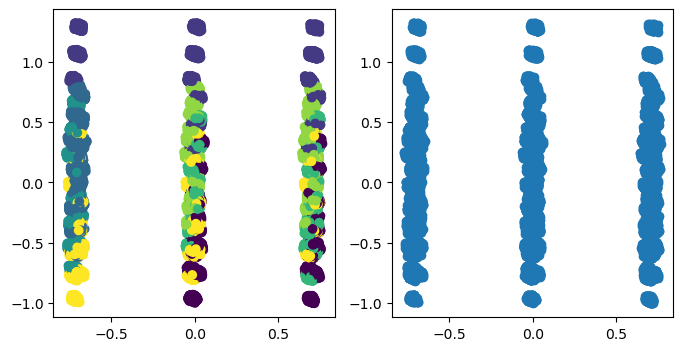

In [9]:
### using the k = 7 finding the clusters
clusters_kmeans(train, train_pca, k = 7)

##### 2. DB scan clustering

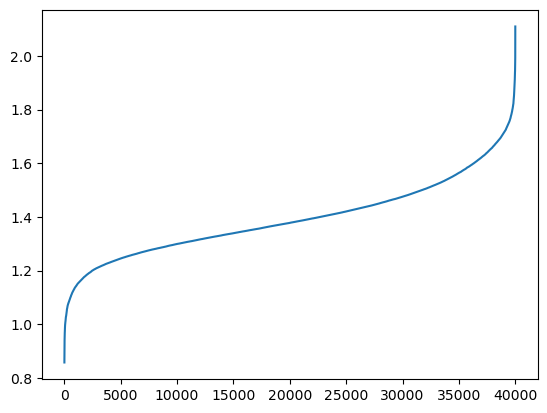

In [10]:
### finding the value of the eps
find_eps(train)

Silhouette score for the full dimensions : -0.30617162184653346
Silhouette score : -0.8521121902799274


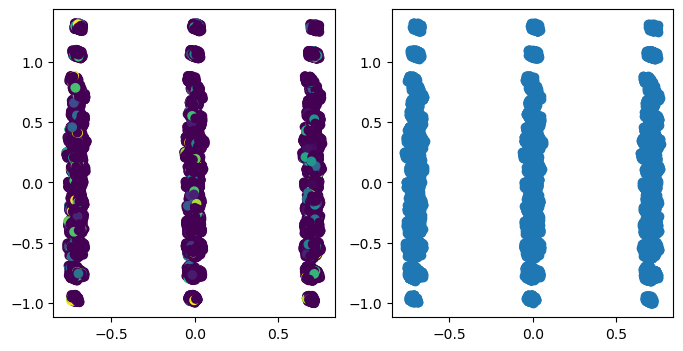

In [12]:
### taking eps = 1.2
clusters_dbscan(train, train_pca, eps = 1.2)

##### 3. HM clustering (Agglomerative clustering)

In [18]:
### taking the sample of only 3000 records
train_hm = sample_for_hm(train, n_samples = 3000)
train_pca_hm = sample_for_hm(train_pca, n_samples = 3000)

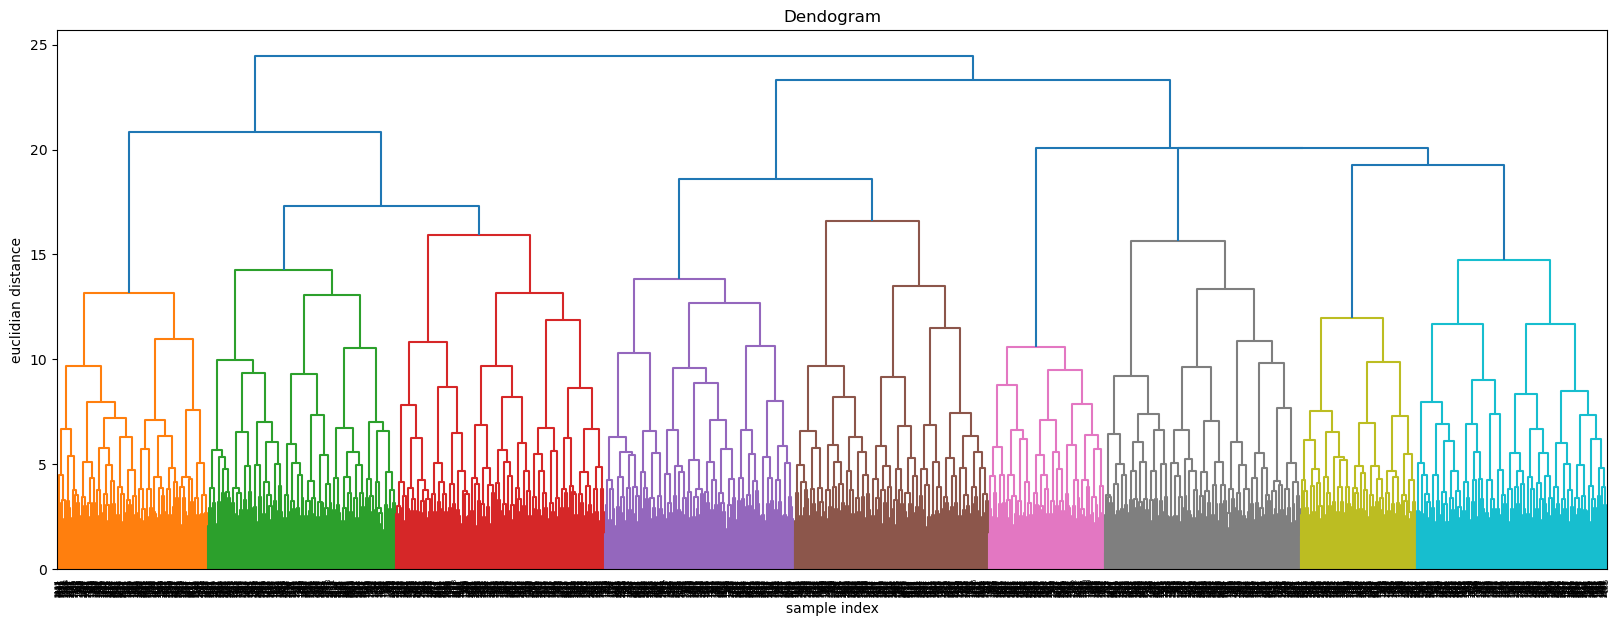

In [19]:
### plotting thr dendogram
plot_dendo(train_hm)

Silhouette score for the full dimensions : 0.008592386098777317
Silhouette score : -0.1176459018481095


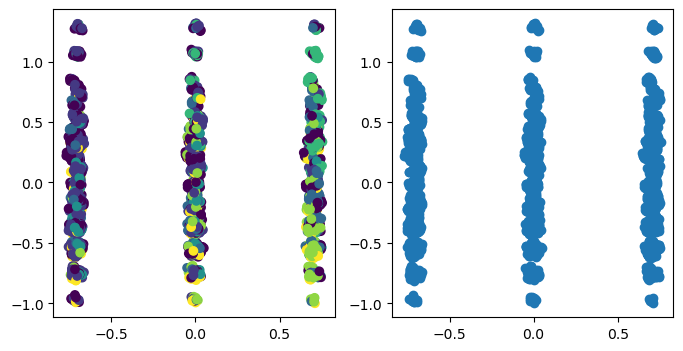

In [20]:
### taking n_clusters = 7 from the dendogram
clusters_hm(train_hm, train_pca_hm, n_clusters = 7)

##### ************ Valid data *****************

In [21]:
### loading the data
valid_path = '../data/unsupervised_ready/valid.csv'
valid = load_data(valid_path)
valid.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,Merchant_Category_Groceries,Merchant_Category_Restaurants,Merchant_Category_Travel,Card_Type_Discover,Card_Type_Mastercard,Card_Type_Visa,Authentication_Method_OTP,Authentication_Method_PIN,Authentication_Method_Password,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0.012998,0,0,0.076923,0.694722,0.75,0.894958,0.913818,0.686537,1,0.090909,0.300000,0.086957,0.265145
1,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0.463744,0,1,0.769231,0.075779,0.25,0.323529,0.059363,0.532206,1,0.181818,0.833333,0.956522,0.371321
2,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0.801443,0,0,0.461538,0.306400,0.50,0.243697,0.958614,0.492398,0,0.636364,0.133333,0.521739,0.324475
3,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,0,1,0,0,0.242247,0,0,0.153846,0.674252,1.00,0.596639,0.663668,0.550310,0,0.000000,0.700000,0.826087,0.336945
4,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0.267799,1,0,0.000000,0.285297,0.00,0.949580,0.114540,0.220744,0,0.636364,0.633333,0.521739,0.407352


In [22]:
### checking the nan, dupliactes and shape
check_nan_duplicates_shape(valid)

Shape : (10000, 33) 
Duplicates : 0 
Transaction_Type_Bank Transfer    0
Transaction_Type_Online           0
Transaction_Type_POS              0
Device_Type_Mobile                0
Device_Type_Tablet                0
Location_Mumbai                   0
Location_New York                 0
Location_Sydney                   0
Location_Tokyo                    0
Merchant_Category_Electronics     0
Merchant_Category_Groceries       0
Merchant_Category_Restaurants     0
Merchant_Category_Travel          0
Card_Type_Discover                0
Card_Type_Mastercard              0
Card_Type_Visa                    0
Authentication_Method_OTP         0
Authentication_Method_PIN         0
Authentication_Method_Password    0
Account_Balance                   0
IP_Address_Flag                   0
Previous_Fraudulent_Activity      0
Daily_Transaction_Count           0
Avg_Transaction_Amount_7d         0
Failed_Transaction_Count_7d       0
Card_Age                          0
Transaction_Distance       

In [23]:
### checking the variance ratio
get_variance(valid)

array([0.07122403, 0.05489973, 0.05429324, 0.05385034, 0.05261984,
       0.05228141, 0.05191584, 0.04471311, 0.04380686, 0.04326874,
       0.04286961, 0.04192523, 0.0416193 , 0.04142487, 0.02655951,
       0.02363224, 0.02084254, 0.02076495, 0.01933743, 0.01880989,
       0.01851522, 0.0180085 , 0.0179045 , 0.01761194, 0.0173235 ,
       0.01718577, 0.01370916, 0.01319578, 0.01284277, 0.00970005,
       0.00846327, 0.00835749, 0.00652337])

In [24]:
### reducing the data for the visualisation (PCA)
valid_pca = reduce_dimensions(valid)
check_shape(valid_pca)

(10000, 2)

##### 1. Kmeans clustering

[47003.75022662736, 44447.51328793799, 42902.245830575324, 41798.368897528184, 40345.3150629975, 40153.21085619821, 39131.8528174341, 38626.924025209315, 38184.83670061008, 37714.57304518255, 37326.3883308271]


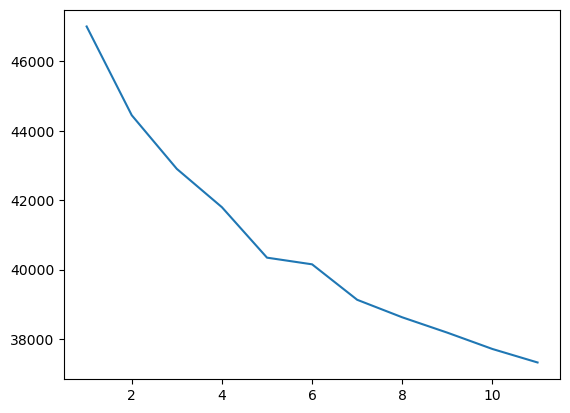

In [25]:
### find the value of the k
find_k(valid)

Silhouette score for the full dimensions : 0.044431607603263416
Silhouette score : 0.07176969355538917


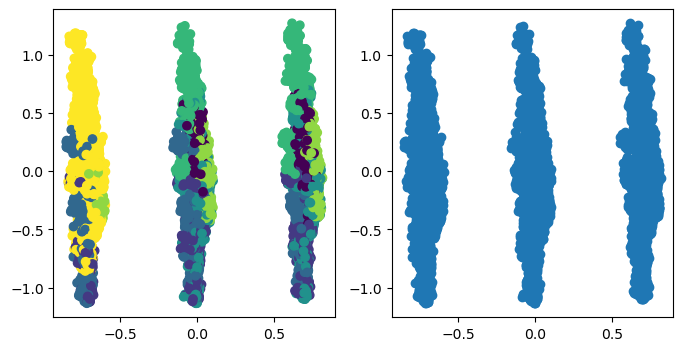

In [26]:
### taking k = 7
clusters_kmeans(valid, valid_pca, k = 7)

##### 2. DBScan clustering

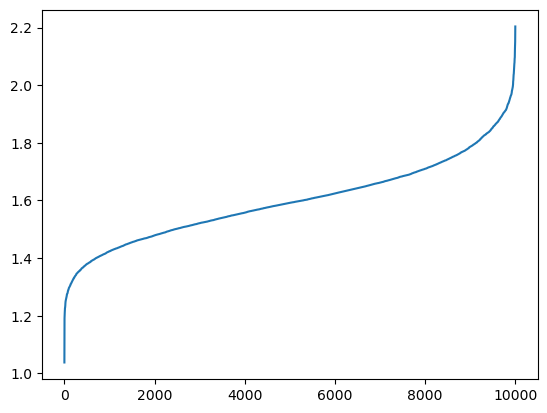

In [27]:
### finding the value of eps
find_eps(valid)

Silhouette score for the full dimensions : -0.2787859120630827
Silhouette score : -0.8629844174798902


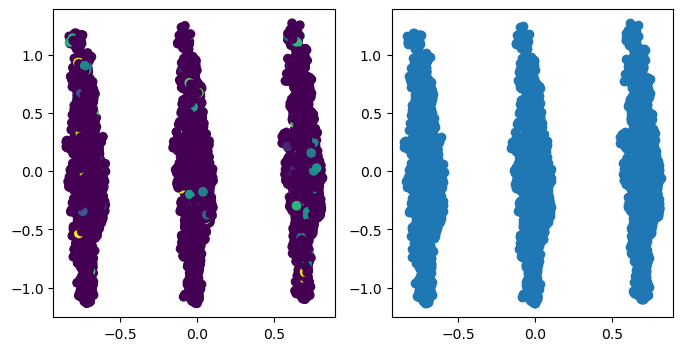

In [28]:
### taking eps = 1.3
clusters_dbscan(valid, valid_pca, eps = 1.3)

##### 3. HM clustering

In [29]:
### taking the sample size of 3000 records only
valid_hm = sample_for_hm(valid, n_samples = 3000)
valid_pca_hm = sample_for_hm(valid_pca, n_samples = 3000)

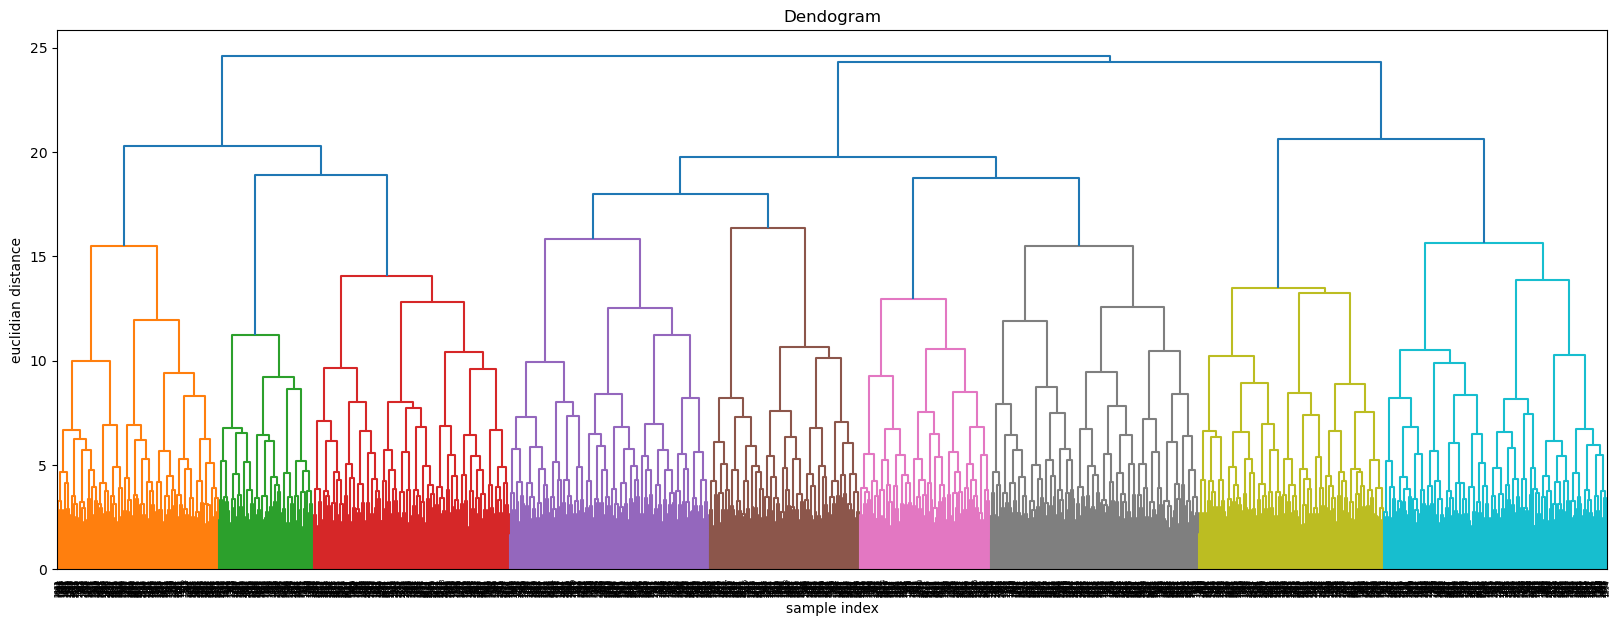

In [30]:
### plotting the dendogram
plot_dendo(valid_hm)

Silhouette score for the full dimensions : 0.00704011522157852
Silhouette score : -0.09859614098862365


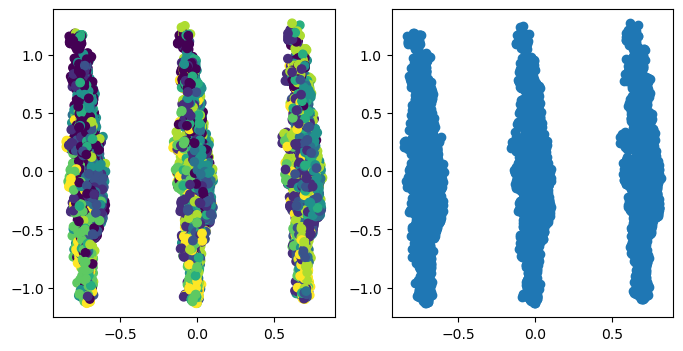

In [31]:
### taking n_clusters = 9
clusters_hm(valid, valid_pca, n_clusters = 9)